# NeuralMD 官方基线：MISATO_1000 实跑与不足诊断

这不是玩具模型。Notebook 直接使用 NeuralMD 作者发布的：

- `MISATO_1000`（800/100/100 complexes，约 7.46 GB）；
- NeuralMD-ODE 官方代码与自定义 `torchdiffeq`；
- `MISATO_1000_seed_42/model.pth` 官方权重；
- MAE、RMSE、Matching、Stability、Ligand collision、Binding collision 官方指标。

执行顺序：3 个测试 complex 的 smoke run → 100 个 unseen test complexes 完整评测 → T1/T2/T3 逐帧失效分析。

> Kaggle 设置：打开 Internet，Accelerator 选择 **T4 x2**（代码只用 GPU 0）。不要选 P100；当前 Kaggle PyTorch 已不包含 P100 的 `sm_60` 内核。首次运行需要下载约 7.46 GB。

## 0. GPU 与运行目录检查

In [5]:
from pathlib import Path
import os
import subprocess
import sys

import torch

WORK = Path("/kaggle/working/neuralmd_official")
RESULTS = Path("/kaggle/working/neuralmd_official_results")
WORK.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neuralmd-matplotlib")

if not torch.cuda.is_available():
    raise RuntimeError("请在 Kaggle Notebook Settings 中启用 T4 GPU。")

capability = torch.cuda.get_device_capability(0)
print("torch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0), "compute capability:", capability)
if capability < (7, 0):
    raise RuntimeError(
        "检测到 P100/sm_60。请把 Kaggle Accelerator 改为 T4 x2 后重新运行；"
        "这样可避免 no kernel image is available。"
    )

torch: 2.10.0+cu128
CUDA runtime: 12.8
GPU: Tesla T4 compute capability: (7, 5)


## 1. 安装与当前 PyTorch 匹配的 PyG 依赖

In [6]:
def pip_install(*packages, extra_args=()):
    command = [sys.executable, "-m", "pip", "install", "-q", *packages, *extra_args]
    print(" ".join(command))
    subprocess.check_call(command)


torch_parts = torch.__version__.split("+")[0].split(".")
pyg_torch = f"{torch_parts[0]}.{torch_parts[1]}.0"
cuda_tag = "cu" + torch.version.cuda.replace(".", "")
pyg_wheels = f"https://data.pyg.org/whl/torch-{pyg_torch}+{cuda_tag}.html"

pip_install("huggingface_hub", "h5py", "pandas", "tqdm", "torch-ema", "torch_geometric")
pip_install("torch_scatter", "torch_cluster", extra_args=("-f", pyg_wheels))

import torch_cluster
import torch_geometric
import torch_scatter
print("PyG:", torch_geometric.__version__)
print("torch_scatter:", torch_scatter.__version__)

/usr/bin/python3 -m pip install -q huggingface_hub h5py pandas tqdm torch-ema torch_geometric
/usr/bin/python3 -m pip install -q torch_scatter torch_cluster -f https://data.pyg.org/whl/torch-2.10.0+cu128.html
PyG: 2.8.0.post1
torch_scatter: 2.1.2+pt210cu128


## 2. 固定代码版本：GOAI evaluator、NeuralMD、torchdiffeq

In [7]:
from pathlib import Path
import shutil
import subprocess


# ============================================================
# 仓库路径
# ============================================================

GOAI = WORK / "goai-protein-ligand-dynamics"
OFFICIAL = WORK / "NeuralMD"
TORCHDIFFEQ = WORK / "torchdiffeq"


# ============================================================
# 固定到 GitHub 上真实存在、可公开拉取的版本
# ============================================================

GOAI_COMMIT = "233a492e4eeacb4c0ae4c86fb2e4745597cb7f47"
OFFICIAL_COMMIT = "a2ae030838c6ea0251eb6a29bfe99dc9d8ee1cfe"
TORCHDIFFEQ_COMMIT = "3d7c7ec8c534a9b18b8b7c7d1fea0c235e6468d0"


def run_command(command, cwd=None):
    """执行命令，同时把完整命令打印出来。"""
    command = [str(item) for item in command]

    print("$", " ".join(command))

    subprocess.check_call(
        command,
        cwd=str(cwd) if cwd is not None else None,
    )


def checkout_repo(url, destination, commit):
    """
    克隆或更新仓库，并精确切换到指定提交。

    已存在的正常 Git 仓库不会被删除。
    只有失败克隆留下的非 Git 目录才会被自动清理。
    """

    destination = Path(destination)

    # 清理之前失败克隆留下的不完整目录
    if destination.exists() and not (destination / ".git").is_dir():
        print(f"[CLEAN] 删除不完整目录：{destination}")
        shutil.rmtree(destination)

    # 首次克隆：先不下载完整历史和文件内容
    if not destination.exists():
        run_command(
            [
                "git",
                "clone",
                "--filter=blob:none",
                "--no-checkout",
                url,
                destination,
            ]
        )

    # 精确拉取目标提交
    run_command(
        [
            "git",
            "fetch",
            "--depth",
            "1",
            "origin",
            commit,
        ],
        cwd=destination,
    )

    # 直接切换到刚刚拉取的提交
    run_command(
        [
            "git",
            "checkout",
            "--detach",
            "--force",
            "FETCH_HEAD",
        ],
        cwd=destination,
    )

    # 校验当前版本，避免静默跑错代码
    revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=str(destination),
        text=True,
    ).strip()

    if revision != commit:
        raise RuntimeError(
            f"{destination.name} 版本校验失败：\n"
            f"实际版本：{revision}\n"
            f"目标版本：{commit}"
        )

    print(f"[OK] {destination.name}: {revision}")


# ============================================================
# 克隆并固定三个仓库
# ============================================================

checkout_repo(
    "https://github.com/ecjtusyy/goai-protein-ligand-dynamics.git",
    GOAI,
    GOAI_COMMIT,
)

checkout_repo(
    "https://github.com/chao1224/NeuralMD.git",
    OFFICIAL,
    OFFICIAL_COMMIT,
)

checkout_repo(
    "https://github.com/chao1224/torchdiffeq.git",
    TORCHDIFFEQ,
    TORCHDIFFEQ_COMMIT,
)


# ============================================================
# 安装官方依赖
# pip_install 使用你 Notebook 前面已经定义的函数
# ============================================================

pip_install("-e", str(TORCHDIFFEQ))
pip_install("-e", str(OFFICIAL))


print("\n[OK] 三个仓库均已固定到指定版本")

$ git fetch --depth 1 origin 233a492e4eeacb4c0ae4c86fb2e4745597cb7f47


From https://github.com/ecjtusyy/goai-protein-ligand-dynamics
 * branch            233a492e4eeacb4c0ae4c86fb2e4745597cb7f47 -> FETCH_HEAD
HEAD is now at 233a492 fix: align NeuralMD evaluation with upstream runtime


$ git checkout --detach --force FETCH_HEAD
[OK] goai-protein-ligand-dynamics: 233a492e4eeacb4c0ae4c86fb2e4745597cb7f47
$ git fetch --depth 1 origin a2ae030838c6ea0251eb6a29bfe99dc9d8ee1cfe


From https://github.com/chao1224/NeuralMD
 * branch            a2ae030838c6ea0251eb6a29bfe99dc9d8ee1cfe -> FETCH_HEAD


$ git checkout --detach --force FETCH_HEAD


...

[OK] NeuralMD: a2ae030838c6ea0251eb6a29bfe99dc9d8ee1cfe
$ git clone --filter=blob:none --no-checkout https://github.com/chao1224/torchdiffeq.git /kaggle/working/neuralmd_official/torchdiffeq
$ git fetch --depth 1 origin 3d7c7ec8c534a9b18b8b7c7d1fea0c235e6468d0


From https://github.com/chao1224/torchdiffeq
 * branch            3d7c7ec8c534a9b18b8b7c7d1fea0c235e6468d0 -> FETCH_HEAD


$ git checkout --detach --force FETCH_HEAD


HEAD is now at 3d7c7ec Updates


[OK] torchdiffeq: 3d7c7ec8c534a9b18b8b7c7d1fea0c235e6468d0
/usr/bin/python3 -m pip install -q -e /kaggle/working/neuralmd_official/torchdiffeq
/usr/bin/python3 -m pip install -q -e /kaggle/working/neuralmd_official/NeuralMD

[OK] 三个仓库均已固定到指定版本


## 3. 获取并严格校验官方 MISATO_1000

In [8]:
from huggingface_hub import snapshot_download

DATA_PARENT = WORK / "data"
DATASET = DATA_PARENT / "MISATO_1000"
mounted = list(Path("/kaggle/input").glob("**/MISATO_1000/raw/MD.hdf5"))

if mounted:
    source_raw = mounted[0].parent
    target_raw = DATASET / "raw"
    target_raw.mkdir(parents=True, exist_ok=True)
    for name in ("MD.hdf5", "train_MD.txt", "val_MD.txt", "test_MD.txt"):
        destination = target_raw / name
        if not destination.exists():
            destination.symlink_to(source_raw / name)
    print("使用 Kaggle 已挂载数据:", source_raw)
else:
    snapshot_download(
        repo_id="chao1224/NeuralMD",
        repo_type="dataset",
        allow_patterns=["MISATO_1000/raw/*"],
        local_dir=DATA_PARENT,
    )
    print("已从 Hugging Face 下载 MISATO_1000")

sys.path.insert(0, str(GOAI))
from src.neuralmd_official import verify_misato1000

dataset_metadata = verify_misato1000(DATASET, strict_size=True)
print(dataset_metadata)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

已从 Hugging Face 下载 MISATO_1000
{'dataset_dir': '/kaggle/working/neuralmd_official/data/MISATO_1000', 'hdf5_bytes': 7455614516, 'split_counts': {'train': 800, 'val': 100, 'test': 100}, 'total_complexes': 1000}


## 4. 下载 seed 42 官方 NeuralMD-ODE 权重

In [9]:
from huggingface_hub import hf_hub_download

CHECKPOINT = Path(
    hf_hub_download(
        repo_id="chao1224/NeuralMD",
        filename="NeuralMD_ODE/MISATO_1000_seed_42/model.pth",
        local_dir=WORK / "checkpoints",
    )
)
HYPERPARAMETERS = Path(
    hf_hub_download(
        repo_id="chao1224/NeuralMD",
        filename="NeuralMD_ODE/MISATO_1000_seed_42/hyperparameter.txt",
        local_dir=WORK / "checkpoints",
    )
)
print("checkpoint:", CHECKPOINT, CHECKPOINT.stat().st_size, "bytes")
print(HYPERPARAMETERS.read_text())
assert CHECKPOINT.stat().st_size == 8_955_570

NeuralMD_ODE/MISATO_1000_seed_42/model.p(…):   0%|          | 0.00/8.96M [00:00<?, ?B/s]

hyperparameter.txt:   0%|          | 0.00/568 [00:00<?, ?B/s]

checkpoint: /kaggle/working/neuralmd_official/checkpoints/NeuralMD_ODE/MISATO_1000_seed_42/model.pth 8955570 bytes
--seed=42 --lr=1e-4 --optimizer=Adam --lr_scheduler=None --FrameNet_num_radial=100 --num_workers=0 --epochs=100 --batch_size=8 --dataset=MISATO_1000 --NeuralMD_step_size=5 --NeuralMD_scaling=100 --NeuralMD_velocity_refined_value_coefficient=0.01 --ODE_method=euler --NeuralMD_binding_model=NeuralMD_Binding01 --no_MLP_velocity --no_NeuralMD_Binding_start_with_first_frame --NeuralMD_Binding_frame_num=10 --output_model_dir=output/MISATO_1000/NeuralMD_Binding01/5_100_0.01_euler_no_NeuralMD_Binding_start_with_first_frame_10_no_MLP_velocity/1e-4_Adam_None_100_8_100_42



## 5. 真实 smoke run：3 个 unseen test complexes

In [11]:
from pathlib import Path
import subprocess
import sys

import torch


# ============================================================
# 0. GPU 检查
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError("当前没有可用 GPU，请在 Kaggle Settings 中启用 T4 GPU。")

gpu_capability = torch.cuda.get_device_capability(0)

print("torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("compute capability:", gpu_capability)

if gpu_capability < (7, 0):
    raise RuntimeError(
        "当前 GPU 不兼容 Kaggle 的 PyTorch CUDA 内核。"
        "请把 Accelerator 改为 T4 x2，不要使用 P100。"
    )


# ============================================================
# 1. 强制修复 NeuralMD 所需的 PyG 运行环境
# ============================================================

def install_package(*packages, extra_args=()):
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *packages,
        *extra_args,
    ]

    print("$", " ".join(command))
    subprocess.check_call(command)


torch_version = torch.__version__.split("+")[0].split(".")
pyg_torch_version = f"{torch_version[0]}.{torch_version[1]}.0"

if torch.version.cuda is None:
    raise RuntimeError("当前 PyTorch 不是 CUDA 版本。")

cuda_tag = "cu" + torch.version.cuda.replace(".", "")

pyg_wheel_index = (
    f"https://data.pyg.org/whl/"
    f"torch-{pyg_torch_version}+{cuda_tag}.html"
)

print("PyG wheel index:", pyg_wheel_index)


# Kaggle 预装的是新版 PyG，这里强制切换到 NeuralMD 兼容版本。
# --no-deps 防止 pip 顺带修改 torch、numpy 等核心包。
install_package(
    "torch_geometric==2.5.3",
    extra_args=(
        "--force-reinstall",
        "--no-deps",
    ),
)

install_package(
    "torch_scatter==2.1.2",
    "torch_cluster==1.6.3",
    extra_args=(
        "--no-index",
        "--force-reinstall",
        "--no-deps",
        "-f",
        pyg_wheel_index,
    ),
)


# ============================================================
# 2. 独立进程执行 radius_graph GPU 探针
# ============================================================

# 必须使用独立进程，避免 Notebook 内核缓存之前的 PyG 2.8。
pyg_probe_code = r'''
import torch
import torch_cluster
import torch_geometric
import torch_scatter

from torch_geometric.nn import radius_graph


print("PyG:", torch_geometric.__version__)
print("torch_scatter:", torch_scatter.__version__)
print("torch_cluster:", torch_cluster.__version__)


if torch_geometric.__version__ != "2.5.3":
    raise RuntimeError(
        f"PyG 版本错误：{torch_geometric.__version__}，预期 2.5.3"
    )


positions = torch.tensor(
    [
        [0.0, 0.0, 0.0],
        [0.5, 0.0, 0.0],
        [3.0, 0.0, 0.0],
    ],
    dtype=torch.float32,
    device="cuda:0",
)

batch = torch.zeros(
    positions.shape[0],
    dtype=torch.long,
    device="cuda:0",
)

edges = radius_graph(
    positions,
    r=1.0,
    batch=batch,
    max_num_neighbors=8,
)

torch.cuda.synchronize()

if edges.shape != (2, 2):
    raise RuntimeError(
        f"radius_graph GPU 探针结果异常：{tuple(edges.shape)}"
    )

print("PyG radius_graph CUDA probe: OK")
'''

subprocess.check_call(
    [
        sys.executable,
        "-c",
        pyg_probe_code,
    ]
)


# ============================================================
# 3. 清理 PyG 2.8 生成的测试缓存
# ============================================================

# 这里只删除约十几秒即可重建的 PyG 测试缓存。
# 不会删除 MISATO_1000 的 7.46 GB 原始数据。
cache_dir = DATASET / "processed_semi_flexible"
cache_file = cache_dir / "geometric_data_processed_test.pt"
runtime_marker = cache_dir / ".goai_pyg_runtime"

runtime_contract = (
    f"torch={pyg_torch_version}+{cuda_tag}\n"
    "pyg=2.5.3\n"
    "torch_scatter=2.1.2\n"
    "torch_cluster=1.6.3\n"
)

old_contract = (
    runtime_marker.read_text()
    if runtime_marker.is_file()
    else None
)

if old_contract != runtime_contract:
    if cache_file.is_file():
        cache_file.unlink()
        print("[CLEAN] 已删除 PyG 2.8 生成的旧测试缓存：", cache_file)

    cache_dir.mkdir(parents=True, exist_ok=True)
    runtime_marker.write_text(runtime_contract)

print("[OK] PyG 数据缓存版本检查完成")


# ============================================================
# 4. 运行官方 NeuralMD smoke test
# ============================================================

SMOKE = RESULTS / "smoke_seed42"


def run_evaluation(output_dir, limit=None):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # 使用模块启动，避免直接运行脚本产生 src 导入路径问题。
    command = [
        sys.executable,
        "-m",
        "scripts.run_official_neuralmd",
        "--official-repo",
        str(OFFICIAL),
        "--dataset-dir",
        str(DATASET),
        "--checkpoint",
        str(CHECKPOINT),
        "--output-dir",
        str(output_dir),
        "--device",
        "cuda:0",
        "--seed",
        "42",
        "--tasks",
        "paper",
        "T1",
        "T2",
        "T3",
    ]

    if limit is not None:
        command.extend(
            [
                "--limit-complexes",
                str(limit),
            ]
        )

    print("\n[NeuralMD]", " ".join(command))

    subprocess.check_call(
        command,
        cwd=str(GOAI),
    )

    summary_path = output_dir / "neuralmd_summary.csv"

    if not summary_path.is_file():
        raise FileNotFoundError(
            f"评估已结束，但没有生成结果文件：{summary_path}"
        )

    return summary_path


smoke_summary = run_evaluation(
    SMOKE,
    limit=3,
)

print("\n[OK] NeuralMD 3-complex smoke test 完成")
print(smoke_summary.read_text(encoding="utf-8"))

torch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
compute capability: (7, 5)
PyG wheel index: https://data.pyg.org/whl/torch-2.10.0+cu128.html
$ /usr/bin/python3 -m pip install -q torch_geometric==2.5.3 --force-reinstall --no-deps
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.3 MB/s eta 0:00:00
$ /usr/bin/python3 -m pip install -q torch_scatter==2.1.2 torch_cluster==1.6.3 --no-index --force-reinstall --no-deps -f https://data.pyg.org/whl/torch-2.10.0+cu128.html
PyG: 2.5.3
torch_scatter: 2.1.2+pt210cu128
torch_cluster: 1.6.3+pt210cu128
PyG radius_graph CUDA probe: OK
[CLEAN] 已删除 PyG 2.8 生成的旧测试缓存： /kaggle/working/neuralmd_official/data/MISATO_1000/processed_semi_flexible/geometric_data_processed_test.pt
[OK] PyG 数据缓存版本检查完成

[NeuralMD] /usr/bin/python3 -m scripts.run_official_neuralmd --official-repo /kaggle/working/neuralmd_official/NeuralMD --dataset-dir /kaggle/working/neuralmd_official/data/MISATO_1

/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/conv/message_passing.py:988: UserWarning: 'EquiMessagePassing.jittable' is deprecated and a no-op. Please remove its usage.
  warnings.warn(f"'{self.__class__.__name__}.jittable' is deprecated "
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:238: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  if osp.exists(f) and torch.load(f) != _repr(self.pre_transform):
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:246: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  if osp.exists(f) and torch.load(f) != _repr(self.pre_filter):
Processing...
100%|██████████| 100/100 [00:16<00:00,  6.24it/s]
Done!
/kaggle/working/neuralmd_offi

Saving...
[preflight] {"ligand_atoms": 16, "protein_residues": 280, "acceleration_abs_max": 0.38095763325691223, "velocity_abs_max": 8.668630599975586, "step_size": 0.05}
[001/003] 3RZB
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[002/003] 4B71
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[003/003] 4W52
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[
  {
    "task": "paper",
    "complexes": 3,
    "frames": 297,
    "mean_mae": 3.798245186958249,
    "mean_rmse": 2.5325300636315586,
    "mean_matching": 0.5985400686260024,
    "mean_stability": 63.4865301369818,
    "mean_ligand_collision": 41.712119725416805,
    "mean_binding_collision": 0.0,
    "mean_com_error": 2.363827231957856,
    "mean_rg_error": 0.39003962157952665
  },
  {
    "task": "T1",
    "complexes": 3,
    "frames": 30,
    "mean_mae": 1.6884720494349799,
    "mean_rms

## 6. 完整评测：100 个 unseen test complexes

Smoke run 成功后，本单元默认继续跑完整测试集。若 Kaggle 会话时间不足，可先把 `RUN_FULL_TEST` 改为 `False`；但初赛正式结论必须来自完整 100 个测试 complex。

In [12]:
RUN_FULL_TEST = True
FULL = RESULTS / "full_seed42"

if RUN_FULL_TEST:
    run_evaluation(FULL)
else:
    print("完整评测已跳过；当前只有 3-complex smoke 结果。")


[NeuralMD] /usr/bin/python3 -m scripts.run_official_neuralmd --official-repo /kaggle/working/neuralmd_official/NeuralMD --dataset-dir /kaggle/working/neuralmd_official/data/MISATO_1000 --checkpoint /kaggle/working/neuralmd_official/checkpoints/NeuralMD_ODE/MISATO_1000_seed_42/model.pth --output-dir /kaggle/working/neuralmd_official_results/full_seed42 --device cuda:0 --seed 42 --tasks paper T1 T2 T3


/usr/local/lib/python3.12/dist-packages/torch_geometric/nn/conv/message_passing.py:988: UserWarning: 'EquiMessagePassing.jittable' is deprecated and a no-op. Please remove its usage.
  warnings.warn(f"'{self.__class__.__name__}.jittable' is deprecated "
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:238: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  if osp.exists(f) and torch.load(f) != _repr(self.pre_transform):
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:246: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  if osp.exists(f) and torch.load(f) != _repr(self.pre_filter):
/kaggle/working/neuralmd_official/NeuralMD/NeuralMD/datasets/MISATO/dataset_MISATO_semi_flexible.py

[preflight] {"ligand_atoms": 16, "protein_residues": 280, "acceleration_abs_max": 0.38095763325691223, "velocity_abs_max": 8.668630599975586, "step_size": 0.05}
[001/100] 3RZB
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[002/100] 4B71
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[003/100] 4W52
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[004/100] 5Q0F
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[005/100] 6MIA
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[006/100] 4WEF
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[007/100] 5AM5
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2: 20 rollout steps
  T3: 80 rollout steps
[008/100] 3S0D
  paper: 99 rollout steps
  T1: 10 rollout steps
  T2:

## 7. 用逐帧指标定位 NeuralMD 的不足

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

analysis_dir = FULL if (FULL / "neuralmd_frames.csv").exists() else SMOKE
frames = pd.read_csv(analysis_dir / "neuralmd_frames.csv")
complexes = pd.read_csv(analysis_dir / "neuralmd_complexes.csv")
summary = pd.read_csv(analysis_dir / "neuralmd_summary.csv")
display(summary)

diagnosis = []
for task, group in frames.groupby("task", sort=False):
    curve = group.groupby("step", as_index=False).mean(numeric_only=True)
    first = curve.iloc[0]
    final = curve.iloc[-1]
    diagnosis.append({
        "task": task,
        "complexes": group["pdb_id"].nunique(),
        "first_rmse": first["rmse"],
        "final_rmse": final["rmse"],
        "rmse_growth_ratio": final["rmse"] / max(first["rmse"], 1e-12),
        "first_stability": first["stability"],
        "final_stability": final["stability"],
        "stability_drop": first["stability"] - final["stability"],
        "final_com_error": final["com_error"],
        "final_rg_error": final["rg_error"],
        "final_ligand_collision": final["ligand_collision"],
        "final_binding_collision": final["binding_collision"],
    })

diagnosis = pd.DataFrame(diagnosis)
diagnosis.to_csv(RESULTS / "weakness_diagnosis.csv", index=False)
display(diagnosis)

,task,complexes,frames,mean_mae,mean_rmse,mean_matching,mean_stability,mean_ligand_collision,mean_binding_collision,mean_com_error,mean_rg_error
0,paper,100,9900,6.680916,4.441304,0.696434,67.215583,15.122525,0.000113,4.051094,0.277318
1,T1,100,1000,2.671033,1.770559,0.480308,78.590935,11.766203,0.001868,1.465095,0.175143
2,T2,100,2000,3.981539,2.641402,0.568384,73.696319,13.048305,0.005921,2.332201,0.220511
3,T3,100,8000,6.253187,4.156142,0.698324,67.632684,13.901388,0.005971,3.745627,0.262927


,task,complexes,first_rmse,final_rmse,rmse_growth_ratio,first_stability,final_stability,stability_drop,final_com_error,final_rg_error,final_ligand_collision,final_binding_collision
0,paper,100,1.321731,6.000664,4.540003,89.613395,62.807131,26.806264,5.512569,0.284465,15.224192,0.000271
1,T1,100,1.108802,2.358037,2.126652,88.299978,73.780476,14.519502,2.006303,0.220286,12.858906,0.001878
2,T2,100,1.459931,3.194884,2.188380,87.817479,68.690848,19.126631,2.895855,0.267050,14.755043,0.005833
3,T3,100,1.209971,5.604010,4.631525,89.263058,61.675092,27.587967,5.129957,0.297070,14.137612,0.006203


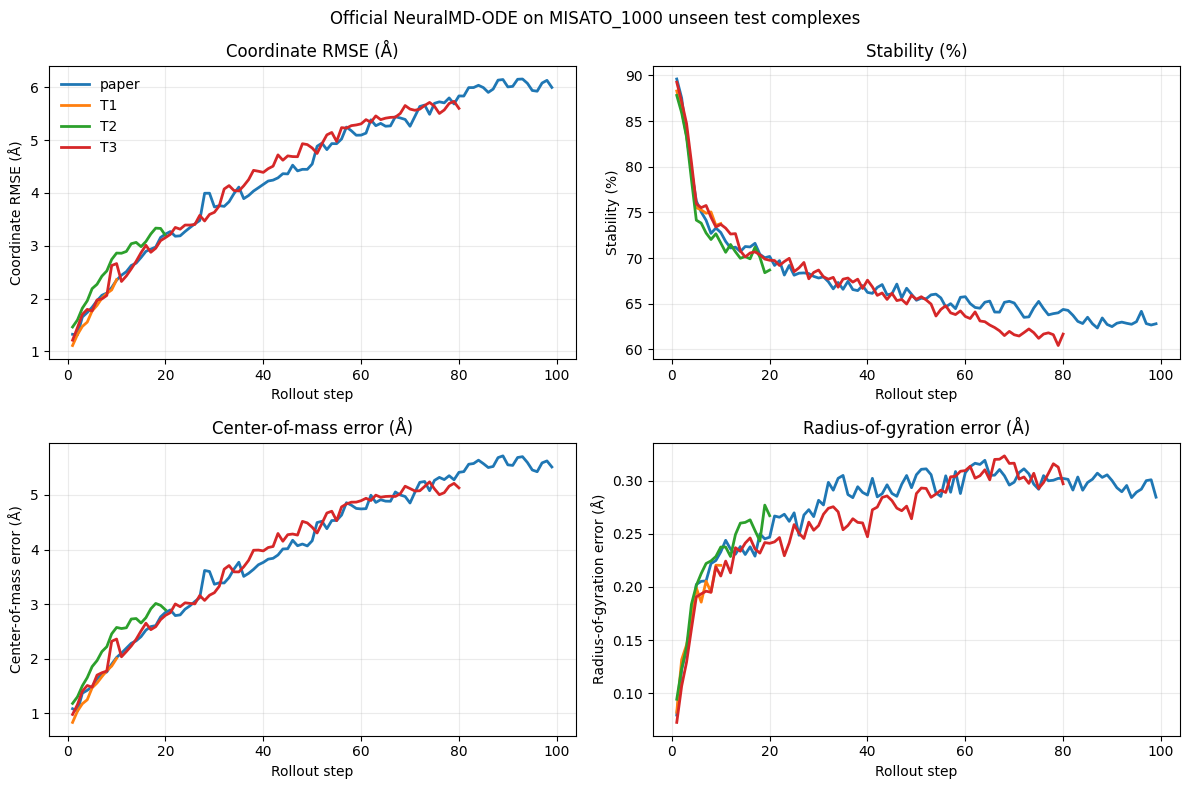

,pdb_id,ligand_atoms,protein_residues,mean_rmse,final_rmse,final_stability,final_com_error,final_rg_error
331,4EZ5,36,252,21.214948,38.750050,65.895065,38.554325,0.083742
363,1K9Q,46,40,13.860659,26.982782,29.111530,25.717815,1.960511
345,3NDM,27,774,12.866595,12.458973,75.308640,12.424542,0.191023
332,3OB0,46,429,12.624952,22.105280,53.875237,22.004692,0.085701
377,4NMX,123,367,10.767828,11.560975,40.723114,11.332504,0.333008
322,6G2R,31,158,9.525476,11.214753,90.218521,11.177827,0.054196
310,3ZXH,27,659,9.499638,9.520519,61.316872,9.448609,0.083983
325,3MEA,36,161,9.117150,12.774260,46.450619,12.423913,0.114389
390,4JRG,35,84,8.766258,10.764716,47.102039,10.306506,0.427078
326,3H91,69,103,8.735236,14.642317,36.147869,13.360013,0.228308


In [15]:
metrics = [
    ("rmse", "Coordinate RMSE (Å)"),
    ("stability", "Stability (%)"),
    ("com_error", "Center-of-mass error (Å)"),
    ("rg_error", "Radius-of-gyration error (Å)"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric, label) in zip(axes.ravel(), metrics):
    for task, group in frames.groupby("task", sort=False):
        curve = group.groupby("step")[metric].mean()
        axis.plot(curve.index, curve.values, label=task, linewidth=2)
    axis.set(xlabel="Rollout step", ylabel=label, title=label)
    axis.grid(alpha=0.25)
axes[0, 0].legend(frameon=False)
fig.suptitle("Official NeuralMD-ODE on MISATO_1000 unseen test complexes")
fig.tight_layout()
curve_path = RESULTS / "neuralmd_failure_curves.png"
fig.savefig(curve_path, dpi=180, bbox_inches="tight")
plt.show()

t3_worst = (
    complexes.query("task == 'T3'")
    .sort_values("mean_rmse", ascending=False)
    .head(15)
)
t3_worst.to_csv(RESULTS / "neuralmd_t3_worst_complexes.csv", index=False)
display(t3_worst[[
    "pdb_id", "ligand_atoms", "protein_residues", "mean_rmse",
    "final_rmse", "final_stability", "final_com_error", "final_rg_error"
]])

## 如何读结果（先诊断，不抢跑改模型）

- `RMSE` 随 rollout 快速增大：优先研究误差累积和训练/推理 horizon 不一致。
- `Stability` 明显下降、`rg_error` 增大：优先研究分子内部几何约束。
- `com_error` 主导而 `rg_error` 较小：优先研究蛋白–配体相互作用与整体漂移。
- ligand/protein 规模与坏样本相关：优先研究固定 cutoff、局部环境容量或显存友好的多尺度表示。
- 若只有少数 complex 发生突变：检查论文已指出的 out-of-distribution sudden positional changes，再决定是否做不确定性/异常运动分支。

先保留这些原始 CSV 和 PNG。下一步改进必须针对完整测试集上实际出现的主导失效模式，而不是预设“加一个模块就会更好”。